In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [75]:
df = pd.read_csv("faturas_financeiro.csv")

In [76]:
df.head()

,ID_Cliente,Segmento,Data_Vencimento,Valor_Boleto,Dias_Atraso,Status
0,CLIE103,Varejo,2025-03-17,1658.06,0,Pago
1,CLIE093,Servicos,2025-03-28,9582.81,0,Pago
2,CLIE015,Servicos,2025-03-27,10626.49,0,Pago
3,CLIE107,Servicos,2025-03-26,570.63,60,Em Aberto
4,CLIE072,Industria,2025-01-27,14049.56,5,Em Aberto


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Cliente       500 non-null    object 
 1   Segmento         500 non-null    object 
 2   Data_Vencimento  500 non-null    object 
 3   Valor_Boleto     500 non-null    float64
 4   Dias_Atraso      500 non-null    int64  
 5   Status           500 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 23.6+ KB


In [78]:
df.describe()

,Valor_Boleto,Dias_Atraso
count,500.000000,500.000000
mean,7598.834740,7.770000
std,4311.725269,18.731761
min,173.610000,0.000000
25%,3686.370000,0.000000
50%,7751.445000,0.000000
75%,11074.147500,5.000000
max,14991.260000,90.000000


In [79]:
#Conferindo as categorias

df["Status"].unique()

array(['Pago', 'Em Aberto'], dtype=object)

In [80]:
inadimplentes = df[df["Dias_Atraso"] > 0]

In [81]:
#Calculando valores

total = df["Valor_Boleto"].sum()
inadimplente = inadimplentes["Valor_Boleto"].sum()
adimplente = total - inadimplente

print(total)
print(inadimplente)
print(adimplente)

3799417.37
1189639.1099999999
2609778.2600000002


([<matplotlib.patches.Wedge at 0x1ce58e4d910>,
 [Text(-0.9157877972772621, 0.6093707495097386, 'Inadimplentes'),
  Text(0.9157877402238506, -0.609370835251978, 'Adimplentes')],
 [Text(-0.49952061669668835, 0.3323840451871301, '31.3%'),
  Text(0.4995205855766457, -0.3323840919556243, '68.7%')])

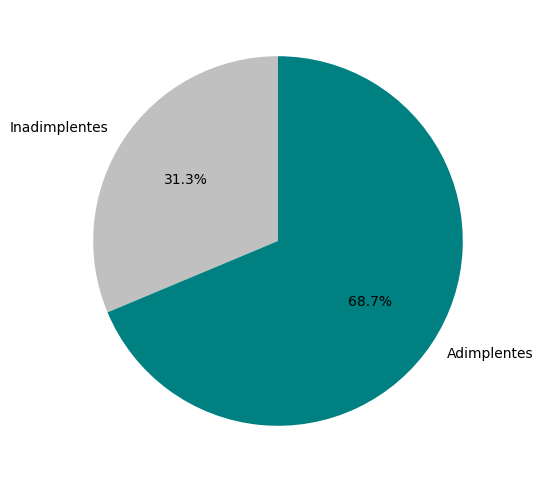

In [82]:
#Gráfico de Pizza

fig, ax1 = plt.subplots(figsize=(10, 6))
plt.pie((inadimplente, adimplente), labels= ("Inadimplentes", "Adimplentes"),autopct='%1.1f%%', startangle=90, colors=[ 'silver','teal'])


In [83]:
# Criando as faixas de Aging (Idade da Dívida)
bins = [0, 30, 60, 90, 999]
labels_atraso = ['Até 30 dias', '31-60 dias', '61-90 dias', '+90 dias']

inadimplentes['Faixa_Atraso'] = pd.cut(inadimplentes['Dias_Atraso'], bins=bins, labels=labels_atraso)

C:\Users\laiso\AppData\Local\Temp\ipykernel_14032\1626744862.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inadimplentes['Faixa_Atraso'] = pd.cut(inadimplentes['Dias_Atraso'], bins=bins, labels=labels_atraso)


In [84]:
# Agrupando para ver o valor total por faixa
resumo_aging = inadimplentes.groupby('Faixa_Atraso', observed=True)['Valor_Boleto'].sum()
print(resumo_aging)

Faixa_Atraso
Até 30 dias    936675.32
31-60 dias     156059.65
61-90 dias      96904.14
Name: Valor_Boleto, dtype: float64


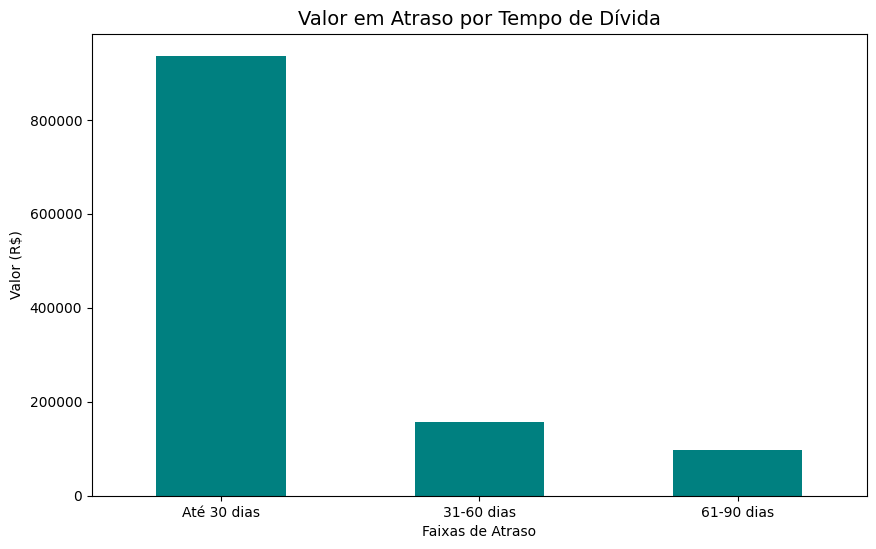

In [85]:
plt.figure(figsize=(10, 6))
resumo_aging.plot(kind='bar', color="teal")

plt.title('Valor em Atraso por Tempo de Dívida', fontsize=14)
plt.ylabel('Valor (R$)')
plt.xlabel('Faixas de Atraso')
plt.xticks(rotation=0)

plt.show()

In [86]:
#Agrupando por cliente
clientes_inadimplentes =inadimplentes.groupby("ID_Cliente")["Valor_Boleto"].sum().sort_values(ascending= False).reset_index()

In [87]:
clientes_inadimplentes.head()

,ID_Cliente,Valor_Boleto
0,CLIE104,38681.62
1,CLIE099,34776.13
2,CLIE101,33851.20
3,CLIE072,28599.89
4,CLIE051,28291.30


In [88]:
clientes_inadimplentes.describe()

,Valor_Boleto
count,97.000000
mean,12264.320722
std,7926.584271
min,552.770000
25%,7031.560000
50%,11624.030000
75%,15701.050000
max,38681.620000


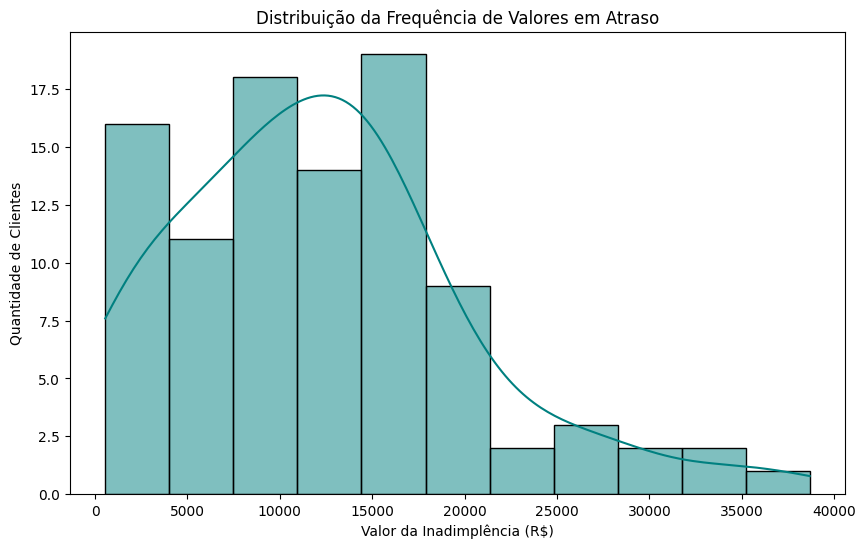

In [89]:
#Criando um Histograma

plt.figure(figsize=(10,6))
sns.histplot(clientes_inadimplentes["Valor_Boleto"], kde=True, color="teal")
plt.title("Distribuição da Frequência de Valores em Atraso")
plt.xlabel("Valor da Inadimplência (R$)")
plt.ylabel("Quantidade de Clientes")
plt.show()

In [90]:
#Preparando os dados para a Análise de Pareto:

# #Adicionando coluna de %

clientes_inadimplentes["% Acumulada"] = (clientes_inadimplentes["Valor_Boleto"].cumsum() / clientes_inadimplentes["Valor_Boleto"].sum())*100

In [91]:
clientes_inadimplentes.describe()

# 50% dos clientes não são suficientes para alcançar 80% da inadimplência acumulada.

,Valor_Boleto,% Acumulada
count,97.000000,97.000000
mean,12264.320722,68.111582
std,7926.584271,28.210230
min,552.770000,3.251542
25%,7031.560000,47.114028
50%,11624.030000,75.163928
75%,15701.050000,93.735741
max,38681.620000,100.000000


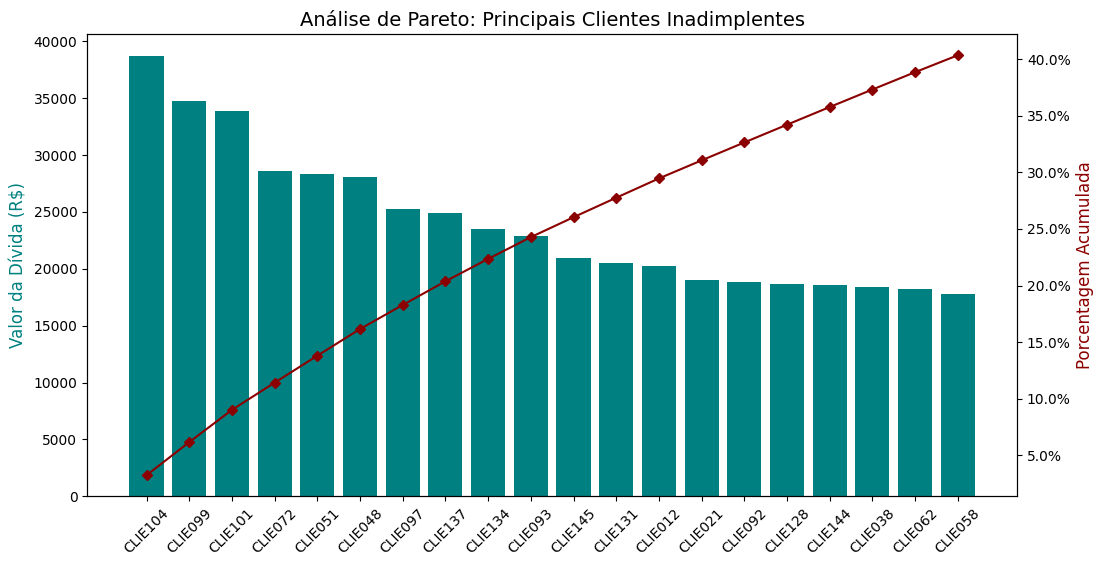

In [98]:
#Análise de Pareto

fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras (Eixo Y Esquerdo)
ax1.bar(clientes_inadimplentes["ID_Cliente"][:20], clientes_inadimplentes["Valor_Boleto"][:20], color="teal")
ax1.set_ylabel("Valor da Dívida (R$)", color="teal", fontsize=12)

# Gráfico de linha (Eixo Y Direito)
ax2 = ax1.twinx()
ax2.plot(clientes_inadimplentes["ID_Cliente"][:20], clientes_inadimplentes["% Acumulada"][:20], color="darkred", marker='D', ms=5)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylabel("Porcentagem Acumulada", color="darkred", fontsize=12)

plt.title("Análise de Pareto: Principais Clientes Inadimplentes", fontsize=14)
ax1.tick_params(axis='x', rotation=45)
plt.show()